# E-Commerce Sales Analysis

## Table of Contents
1. [Introduction and Business Objectives](#Introduction-and-Business-Objectives)
2. [Data Dictionary](#Data-Dictionary)
3. [Configuration](#Configuration)
4. [Data Loading and Preparation](#Data-Loading-and-Preparation)
5. [Revenue Analysis](#Revenue-Analysis)
6. [Order Value and Volume Analysis](#Order-Value-and-Volume-Analysis)
7. [Product Category Analysis](#Product-Category-Analysis)
8. [Geographic Analysis](#Geographic-Analysis)
9. [Customer Experience Analysis](#Customer-Experience-Analysis)
10. [Summary of Observations](#Summary-of-Observations)

## Introduction and Business Objectives

This notebook analyzes e-commerce order data to answer a recurring set of business questions:

- How much revenue was generated in the analysis period, and how does it compare to the prior period?
- What is the month-over-month revenue trend within the analysis period?
- What is the average order value and order volume, and how do they compare to the prior period?
- Which product categories and states generate the most revenue?
- How does delivery speed relate to customer satisfaction (review score)?
- What share of orders are delivered, canceled, or still in progress?

The analysis period and the comparison period are both configurable (see the Configuration section), so the same notebook can be re-run for any month or year without changing any calculation logic. All metric calculations live in `business_metrics.py`; all data loading and preparation logic lives in `data_loader.py`.

## Data Dictionary

| Table | Column | Description |
|---|---|---|
| orders | order_id | Unique identifier for an order |
| orders | customer_id | Identifier of the customer who placed the order |
| orders | order_status | Order status: delivered, shipped, canceled, processing, pending, or returned |
| orders | order_purchase_timestamp | Timestamp when the order was placed |
| orders | order_delivered_customer_date | Timestamp when the order reached the customer (null if not yet delivered) |
| order_items | order_id | Order the line item belongs to |
| order_items | order_item_id | Line number within the order |
| order_items | product_id | Product sold in this line item |
| order_items | price | Price of this line item, in USD |
| products | product_id | Unique identifier for a product |
| products | product_category_name | Product category |
| customers | customer_id | Unique identifier for a customer |
| customers | customer_state | US state of the customer |
| reviews | order_id | Order the review refers to |
| reviews | review_score | Customer satisfaction score, 1 (worst) to 5 (best) |

### Business terms used in this notebook

- **Revenue**: sum of `order_items.price` for delivered orders in the period.
- **Order value**: revenue per order (line items summed per `order_id`).
- **Delivery time**: days between `order_purchase_timestamp` and `order_delivered_customer_date`.
- **Delivery-speed bucket**: a configurable grouping of delivery time (see Configuration section) used to relate delivery speed to review scores.
- **Period-over-period change**: percentage change between the analysis period and the comparison period.

## Configuration

All period-specific and business-rule parameters are defined in one place below. To re-run this analysis for a different month, year, or delivery-speed grouping, change the values in `CONFIG` only; no other cell needs to change.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

sys.path.append(str(Path.cwd()))

import data_loader as dl
import business_metrics as bm

In [2]:
CONFIG = {
    "data_dir": Path("ecommerce_data"),
    "current_year": 2023,
    "current_month": None,   # None analyzes the full year; set 1-12 to analyze a single month
    "comparison_year": 2022,
    "comparison_month": None,
    "delivery_speed_bins": [0, 3, 7, float("inf")],
    "delivery_speed_labels": ["1-3 days", "4-7 days", "8+ days"],
}


def describe_period(year: int, month: int | None) -> str:
    """Return a human-readable label for a configured year/month period."""
    if month is None:
        return str(year)
    return f"{pd.Timestamp(year=year, month=month, day=1):%B %Y}"


CURRENT_PERIOD_LABEL = describe_period(CONFIG["current_year"], CONFIG["current_month"])
COMPARISON_PERIOD_LABEL = describe_period(CONFIG["comparison_year"], CONFIG["comparison_month"])

print(f"Analysis period: {CURRENT_PERIOD_LABEL}")
print(f"Comparison period: {COMPARISON_PERIOD_LABEL}")

Analysis period: 2023
Comparison period: 2022


### Chart style

A single business-oriented color scheme is defined once and reused across every chart in this notebook, so figures stay visually consistent.

In [3]:
plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#0b0b0b",
    "text.color": "#0b0b0b",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
    "grid.color": "#e1e0d9",
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
})

CHART_PRIMARY_COLOR = "#2a78d6"        # single-series magnitude (sequential blue)
CHART_SEQUENTIAL_SCALE = "Blues"       # plotly sequential scale, used for the choropleth

## Data Loading and Preparation

Loads the raw CSV files, joins them into a single order-line-level sales table, and restricts the table to delivered orders, since revenue and customer-experience metrics should only reflect completed transactions. Order status for all orders (not just delivered) is examined separately in the Customer Experience section.

In [4]:
raw = dl.load_datasets(CONFIG["data_dir"])
orders = raw["orders"]
order_items = raw["order_items"]
products = raw["products"]
customers = raw["customers"]
reviews = raw["reviews"]

sales = dl.build_order_line_sales(orders, order_items)
sales_delivered = dl.filter_delivered_orders(sales)
sales_delivered = dl.add_delivery_days(sales_delivered)

print(f"Total order lines: {len(sales):,}")
print(f"Delivered order lines: {len(sales_delivered):,}")

Total order lines: 16,047
Delivered order lines: 15,095


In [5]:
current_sales = dl.filter_period(sales_delivered, CONFIG["current_year"], CONFIG["current_month"])
comparison_sales = dl.filter_period(sales_delivered, CONFIG["comparison_year"], CONFIG["comparison_month"])

print(f"Delivered order lines in {CURRENT_PERIOD_LABEL}: {len(current_sales):,}")
print(f"Delivered order lines in {COMPARISON_PERIOD_LABEL}: {len(comparison_sales):,}")

Delivered order lines in 2023: 7,448
Delivered order lines in 2022: 7,641


## Revenue Analysis

Total revenue, period-over-period growth, and the month-over-month trend within the analysis period.

In [6]:
current_revenue = bm.calculate_total_revenue(current_sales)
comparison_revenue = bm.calculate_total_revenue(comparison_sales)
revenue_growth_pct = bm.calculate_percent_change(current_revenue, comparison_revenue)

print(f"Total revenue in {CURRENT_PERIOD_LABEL}: ${current_revenue:,.2f}")
print(f"Total revenue in {COMPARISON_PERIOD_LABEL}: ${comparison_revenue:,.2f}")
print(f"Revenue change vs {COMPARISON_PERIOD_LABEL}: {revenue_growth_pct:.2f}%")

Total revenue in 2023: $3,360,294.74
Total revenue in 2022: $3,445,076.96
Revenue change vs 2022: -2.46%


In [7]:
monthly_revenue = bm.calculate_monthly_revenue(current_sales)
monthly_growth_pct = bm.calculate_month_over_month_growth(monthly_revenue)

print(f"Average month-over-month revenue growth in {CURRENT_PERIOD_LABEL}: {monthly_growth_pct.mean():.2f}%")
monthly_growth_pct

Average month-over-month revenue growth in 2023: -0.39%


month
1           NaN
2     -2.842473
3      3.201430
4    -11.142177
5     18.736938
6     -4.055524
7      2.449677
8     -3.228726
9      5.982143
10   -14.451610
11    -0.142837
12     1.239409
Name: price, dtype: float64

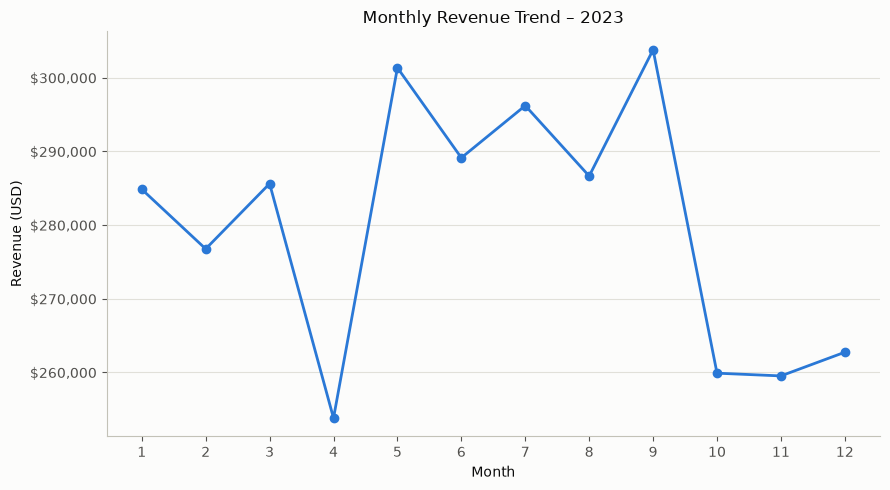

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(
    monthly_revenue.index,
    monthly_revenue.values,
    color=CHART_PRIMARY_COLOR,
    marker="o",
    linewidth=2,
)
ax.set_title(f"Monthly Revenue Trend \u2013 {CURRENT_PERIOD_LABEL}")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue (USD)")
ax.set_xticks(range(1, 13))
ax.grid(True, axis="y", linewidth=0.8)
ax.yaxis.set_major_formatter(lambda value, _: f"${value:,.0f}")
plt.tight_layout()
plt.show()

## Order Value and Volume Analysis

Average order value and total order count, both compared against the comparison period.

In [9]:
current_aov = bm.calculate_average_order_value(current_sales)
comparison_aov = bm.calculate_average_order_value(comparison_sales)
aov_growth_pct = bm.calculate_percent_change(current_aov, comparison_aov)

print(f"Average order value in {CURRENT_PERIOD_LABEL}: ${current_aov:,.2f}")
print(f"Average order value change vs {COMPARISON_PERIOD_LABEL}: {aov_growth_pct:.2f}%")

Average order value in 2023: $724.98
Average order value change vs 2022: -0.06%


In [10]:
current_order_count = bm.calculate_order_count(current_sales)
comparison_order_count = bm.calculate_order_count(comparison_sales)
order_count_growth_pct = bm.calculate_percent_change(current_order_count, comparison_order_count)

print(f"Number of orders in {CURRENT_PERIOD_LABEL}: {current_order_count:,}")
print(f"Order count change vs {COMPARISON_PERIOD_LABEL}: {order_count_growth_pct:.2f}%")

Number of orders in 2023: 4,635
Order count change vs 2022: -2.40%


## Product Category Analysis

Revenue attributed to each product category in the analysis period, based on the category of the product sold in each order line.

In [11]:
current_sales_with_category = dl.attach_product_category(current_sales, products)
revenue_by_category = bm.calculate_revenue_by_dimension(current_sales_with_category, "product_category_name")
revenue_by_category

product_category_name
electronics               1401359.21
home_garden                862653.27
sports_outdoors            278845.32
automotive                 247707.10
clothing_shoes_jewelry     232745.04
toys_games                  70163.64
health_personal_care        65370.27
tools_home_improvement      54280.33
beauty_personal_care        49213.30
books_media                 38559.08
grocery_gourmet_food        26964.36
baby_products               25302.54
pet_supplies                 7131.28
Name: price, dtype: float64

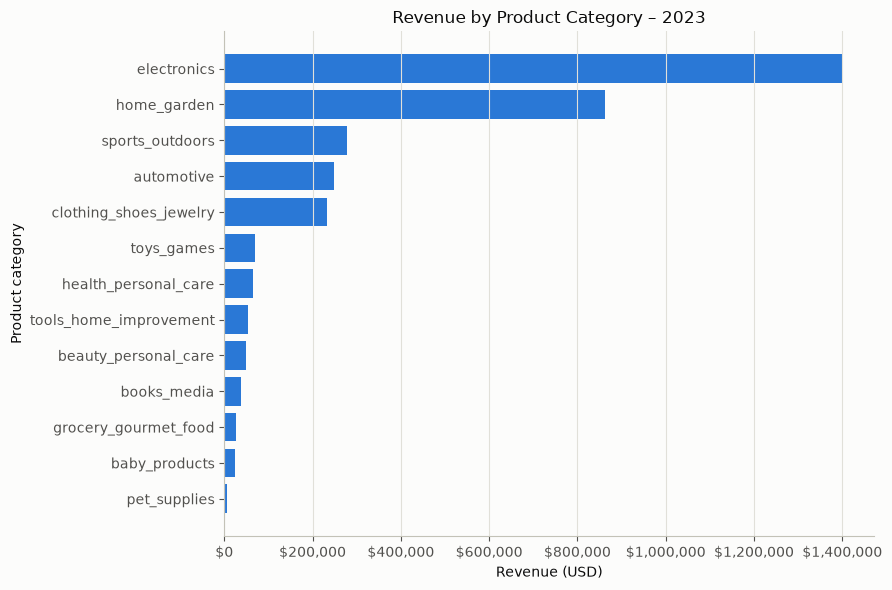

In [12]:
fig, ax = plt.subplots(figsize=(9, 6))
ordered_categories = revenue_by_category.sort_values()
ax.barh(ordered_categories.index, ordered_categories.values, color=CHART_PRIMARY_COLOR)
ax.set_title(f"Revenue by Product Category \u2013 {CURRENT_PERIOD_LABEL}")
ax.set_xlabel("Revenue (USD)")
ax.set_ylabel("Product category")
ax.xaxis.set_major_formatter(lambda value, _: f"${value:,.0f}")
ax.grid(True, axis="x", linewidth=0.8)
plt.tight_layout()
plt.show()

## Geographic Analysis

Revenue attributed to each US state, based on the state of the customer who placed the order.

In [13]:
current_sales_with_state = dl.attach_customer_state(current_sales, customers)
revenue_by_state = bm.calculate_revenue_by_dimension(current_sales_with_state, "customer_state").reset_index()
revenue_by_state.columns = ["customer_state", "revenue"]
revenue_by_state.head()

,customer_state,revenue
0,CA,537880.74
1,TX,403303.49
2,FL,310195.84
3,NY,253111.85
4,IL,185930.89


In [14]:
fig = px.choropleth(
    revenue_by_state,
    locations="customer_state",
    color="revenue",
    locationmode="USA-states",
    scope="usa",
    title=f"Revenue by State \u2013 {CURRENT_PERIOD_LABEL}",
    color_continuous_scale=CHART_SEQUENTIAL_SCALE,
    labels={"revenue": "Revenue (USD)"},
)
fig.update_layout(coloraxis_colorbar={"title": "Revenue (USD)"})
fig.show()

## Customer Experience Analysis

Delivery speed (days between purchase and customer delivery), its relationship with review scores, the overall review score distribution, and the order status mix for all orders placed in the analysis period.

Delivery-speed buckets are configurable in `CONFIG["delivery_speed_bins"]` / `CONFIG["delivery_speed_labels"]` rather than fixed in the calculation logic.

In [15]:
current_sales_with_reviews = dl.attach_review_score(current_sales, reviews)
order_level_experience = dl.get_order_level_view(
    current_sales_with_reviews, ["order_id", "delivery_days", "review_score"]
)

average_review_score = bm.calculate_average_review_score(order_level_experience)
average_delivery_days = bm.calculate_average_delivery_days(order_level_experience)

print(f"Average review score in {CURRENT_PERIOD_LABEL}: {average_review_score:.2f} (scale 1-5)")
print(f"Average delivery time in {CURRENT_PERIOD_LABEL}: {average_delivery_days:.2f} days")

Average review score in 2023: 4.10 (scale 1-5)
Average delivery time in 2023: 8.01 days


In [16]:
review_score_by_delivery_day = bm.calculate_average_review_score_by_group(
    order_level_experience, "delivery_days"
)
review_score_by_delivery_day

,delivery_days,review_score
0,2,4.033898
1,3,4.248555
2,4,4.068000
3,5,4.054054
4,6,4.073529
5,7,4.102236
6,8,3.965418
7,9,4.117470
8,10,4.100917
9,11,4.146580


In [17]:
order_level_experience_bucketed = bm.categorize_delivery_speed(
    order_level_experience,
    bin_edges=CONFIG["delivery_speed_bins"],
    bin_labels=CONFIG["delivery_speed_labels"],
)
review_score_by_delivery_bucket = bm.calculate_average_review_score_by_group(
    order_level_experience_bucketed, "delivery_speed_bucket"
)
review_score_by_delivery_bucket

,delivery_speed_bucket,review_score
0,1-3 days,4.193966
1,4-7 days,4.075063
2,8+ days,4.108138


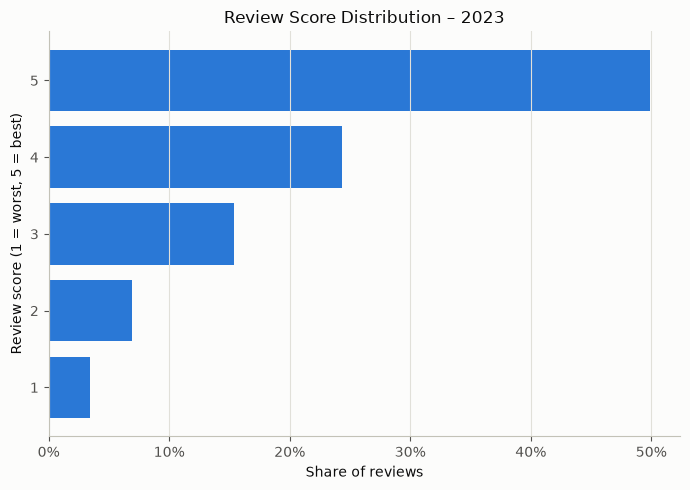

In [18]:
review_score_distribution = bm.calculate_review_score_distribution(order_level_experience)

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(
    review_score_distribution.index.astype(str),
    review_score_distribution.values,
    color=CHART_PRIMARY_COLOR,
)
ax.set_title(f"Review Score Distribution \u2013 {CURRENT_PERIOD_LABEL}")
ax.set_xlabel("Share of reviews")
ax.set_ylabel("Review score (1 = worst, 5 = best)")
ax.xaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
ax.grid(True, axis="x", linewidth=0.8)
plt.tight_layout()
plt.show()

In [19]:
orders_with_period = dl.add_period_columns(orders, "order_purchase_timestamp")
current_orders = dl.filter_period(orders_with_period, CONFIG["current_year"], CONFIG["current_month"])
order_status_distribution = bm.calculate_order_status_distribution(current_orders)

print(f"Order status distribution in {CURRENT_PERIOD_LABEL}:")
order_status_distribution

Order status distribution in 2023:


order_status
delivered     0.936364
shipped       0.031919
canceled      0.012929
processing    0.011919
pending       0.005051
returned      0.001818
Name: proportion, dtype: float64

## Summary of Observations

The cell below prints a consolidated summary of every metric calculated above, using the period currently set in `CONFIG`. Re-running the notebook with a different `CONFIG` produces an updated summary automatically.

In [20]:
top_category = revenue_by_category.index[0]
top_category_revenue = revenue_by_category.iloc[0]
top_state_row = revenue_by_state.sort_values("revenue", ascending=False).iloc[0]

print("Summary of Observations")
print("=" * 60)
print(f"Analysis period: {CURRENT_PERIOD_LABEL} (compared to {COMPARISON_PERIOD_LABEL})")
print(f"- Revenue: ${current_revenue:,.2f} ({revenue_growth_pct:+.2f}% vs comparison period)")
print(f"- Average order value: ${current_aov:,.2f} ({aov_growth_pct:+.2f}% vs comparison period)")
print(f"- Orders: {current_order_count:,} ({order_count_growth_pct:+.2f}% vs comparison period)")
print(f"- Average month-over-month revenue growth: {monthly_growth_pct.mean():.2f}%")
print(f"- Top revenue product category: {top_category} (${top_category_revenue:,.2f})")
print(f"- Top revenue state: {top_state_row['customer_state']} (${top_state_row['revenue']:,.2f})")
print(f"- Average review score: {average_review_score:.2f} / 5")
print(f"- Average delivery time: {average_delivery_days:.2f} days")
print(f"- Share of orders delivered: {order_status_distribution.get('delivered', 0):.2%}")

Summary of Observations
Analysis period: 2023 (compared to 2022)
- Revenue: $3,360,294.74 (-2.46% vs comparison period)
- Average order value: $724.98 (-0.06% vs comparison period)
- Orders: 4,635 (-2.40% vs comparison period)
- Average month-over-month revenue growth: -0.39%
- Top revenue product category: electronics ($1,401,359.21)
- Top revenue state: CA ($537,880.74)
- Average review score: 4.10 / 5
- Average delivery time: 8.01 days
- Share of orders delivered: 93.64%
